<a href="https://colab.research.google.com/github/Loading-my-brain/GEOG761_Remote_Sensing/blob/main/Labs/Lab2_Tasks_only_hnis651.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set Up

In [47]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='earthengine-ml-testing-502922')

# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

In [48]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map



Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [49]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10 #0: No opaque clouds
    cirrusBitMask = 1 << 11 #0: No cirrus clouds
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

    #Band 2 (B2): Blue light (~492 nm), 10 m resolution, used for soil/vegetation discrimination and atmospheric scatter tracking.
    #Band 3 (B3): Green light (~560 nm), 10 m resolution, used for assessing peak vegetation reflectance.
    #Band 4 (B4): Red light (~665 nm), 10 m resolution, crucial for chlorophyll absorption and red-edge calculations.
    #Band 8 (B8): Broad Near-Infrared (NIR, ~842 nm), 10 m resolution, primary channel for biomass and robust vegetation indexing (NDVI).

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

# All Tasks

---

# Task 1

(1) What other mathematical [compositing](https://developers.google.com/earth-engine/guides/ic_composite_mosaic) approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)




---


In [50]:
# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map = geemap.Map(center=[-41.3, 174.75], zoom=11) #<- reset the map object to clear out other layers from earlier cells
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [51]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Need to change this to sequential list to avoid the algs thiniing there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')
landcover_remapped

---

# Task 2

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)


---

In [52]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped).addBands(landcover_remapped)


In [53]:
# HInami's notes:

# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,#region=aoi: Restricts sampling within your Area of Interest polygon (Wellington region).
    scale=10, #scale=10: Sets the spatial resolution to 10 meters per pixel, matching Sentinel-2's highest resolution bands.
    numPixels=5000, #Requests up to 5,000 random pixel points across the region.
    seed=2,#Sets a fixed random seed to ensure reproducibility (so re-running the code yields the exact same sample points).
    geometries=True)#Retains geographic spatial coordinates (latitude/longitude) for each sample point.

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()#Pulls the first 10 sample points from Google's servers to your local client session.

print('\nFirst 10 training samples:')
#Iterates through those 10 features and prints out their land cover class ID
 #(Map_remapped) alongside their corresponding surface reflectance values across bands B2, B3, B4, and B8.
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns( #Runs a server-side aggregation across all sampled points.
    reducer=ee.Reducer.frequencyHistogram(),#Counts how many pixels were sampled for each land cover class.
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())
#Returns the histogram summary (e.g., how many pixels fell into Class 1, Class 8, etc.),
# allowing you to check for class imbalance before training models like Random Forest or SVM.



First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3140000104904175
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

# Task 3


(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)


In [54]:
# Hinami's Notes:


# Add random column
sample = sample.randomColumn('random')
#Adds a new property named 'random' to every feature (pixel sample point) in your dataset.
# How it works: GEE assigns each sample point a *uniformly* distributed pseudo-random float between
#0.0 and 1.0 (e.g., 0.142, 0.785, 0.923)

# Split
train = sample.filter(ee.Filter.lt('random', 0.7))
#ee.Filter.lt('random', 0.7): Filters for features where the random value is less
#than 0.7 ([0.0, 0.7)).Purpose: Provides 70% of the data for the Random Forest
#classifier to learn patterns between the spectral bands and landcover classes.

valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

In [55]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

# Classify image
classified = s2.select(bands).classify(classifier)

In [56]:
# Classified image viz, fresh set up again to make sure we have exactly what we want displayed.
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(classified.randomVisualizer(), {}, 'Classified')
Map.addLayer(landcover_remapped.randomVisualizer(), {} ,'ESA Landcover')
Map

Map(center=[-41.30004624634492, 174.74999999999935], controls=(WidgetControl(options=['position', 'transparent…

---

# Task 4

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

---

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Validate
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Pretty-print
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

---

# Task 5

(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:
*   Landcover maps of Wellington for 2018, 2022 and 2024
*   The Test accuracy averages of the RF classifier for 2020.
*   Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)



=== 2020 Model Test Accuracy ===
Overall Accuracy: 0.9022633744855967
Kappa Statistic: 0.8422568510818577


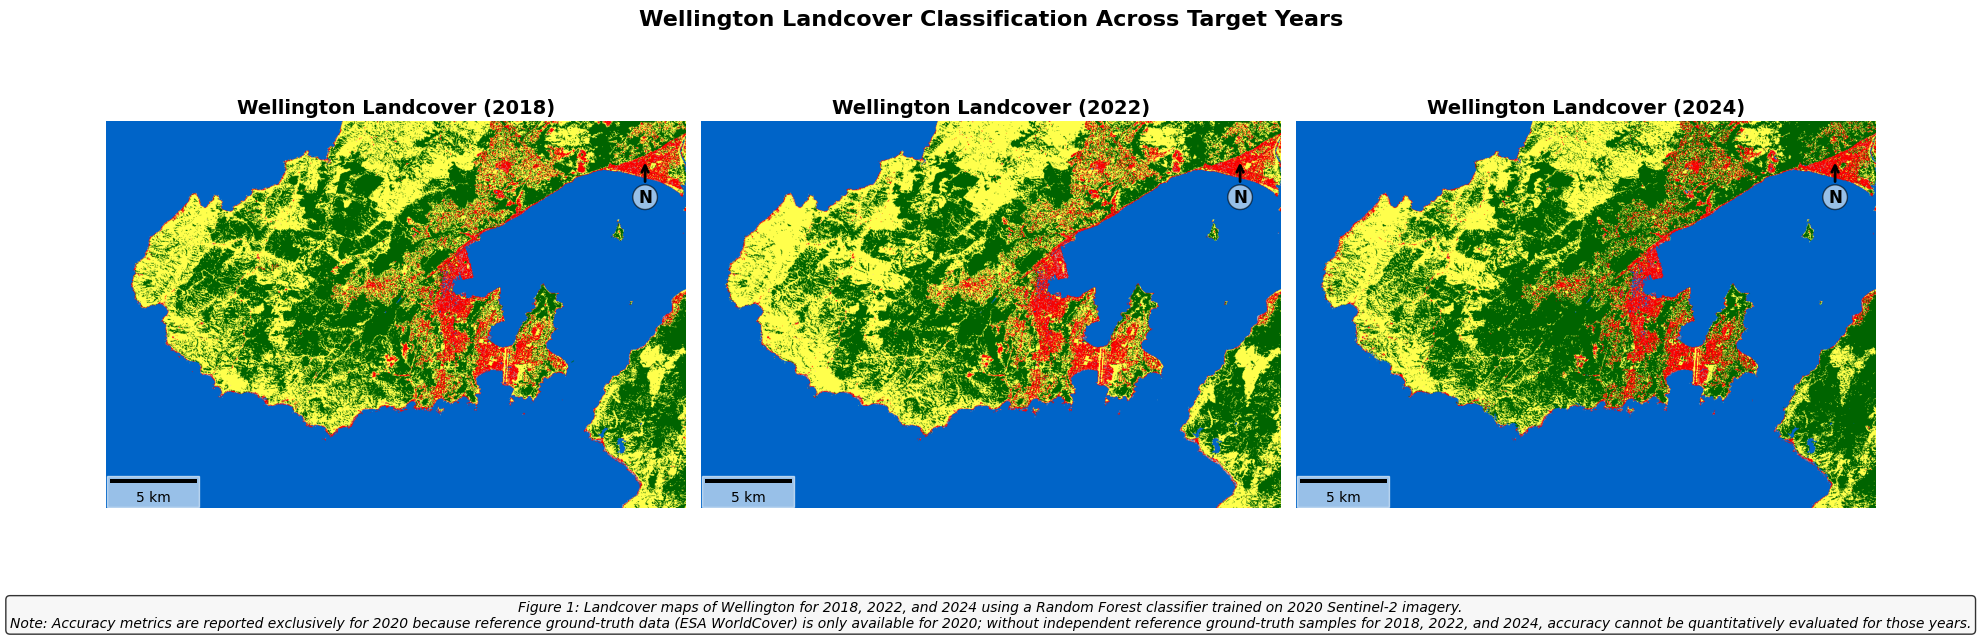

In [61]:
# !pip install matplotlib-scalebar --quiet
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar

# Train RF Model on 2020 Data & Compute Test Accuracy
bands = ['B2', 'B3', 'B4', 'B8']

# Split 2020 sample data (80% train, 20% test)
sample_with_random = sample.randomColumn('random', seed=42)
train_samples = sample_with_random.filter(ee.Filter.lt('random', 0.8))
test_samples = sample_with_random.filter(ee.Filter.gte('random', 0.8))

# Train Random Forest Model
rf_classifier = ee.Classifier.smileRandomForest(100).train(
    features=train_samples,
    classProperty='Map_remapped',
    inputProperties=bands
)

# Compute Test Accuracy on 2020 validation split
test_results = test_samples.classify(rf_classifier)
error_matrix = test_results.errorMatrix('Map_remapped', 'classification')

print("=== 2020 Model Test Accuracy ===")
print("Overall Accuracy:", error_matrix.accuracy().getInfo())
print("Kappa Statistic:", error_matrix.kappa().getInfo())


# Get Sentinel-2 Composites & Classify 2018, 2022, 2024
def get_s2_composite(year):
    return (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(aoi)
            .filterDate(f'{year}-01-01', f'{year}-12-31')
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
            .map(mask_s2_clouds)
            .median()
            .clip(aoi))

years = [2018, 2022, 2024]
classified_maps = {}

for yr in years:
    s2_img = get_s2_composite(yr)
    classified_maps[yr] = s2_img.select(bands).classify(rf_classifier)


# Create Publication Figure & Caption
palette = ['006400', 'ffbb22', 'ffff4c', 'f096ff', 'fa0000', 'b4b4b4', 'f0f0f0', '0064c8', '0096a0', '00cf75']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, yr in zip(axes, years):
    cmap = classified_maps[yr]
    img_array = geemap.ee_to_numpy(
        cmap.visualize(min=1, max=10, palette=palette),
        region=aoi,
        scale=30
    )
    ax.imshow(img_array)
    ax.set_title(f"Wellington Landcover ({yr})", fontsize=14, fontweight='bold')

    #dd Scale Bar (scale=30m per pixel)
    scalebar = ScaleBar(
        dx=30,
        units="m",
        location="lower left",
        box_alpha=0.6,
        color="black"
    )
    ax.add_artist(scalebar)

    # Add North Arrow
    ax.annotate(
        'N', xy=(0.93, 0.90), xytext=(0.93, 0.78),
        xycoords='axes fraction', textcoords='axes fraction',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold',
        arrowprops=dict(arrowstyle='->', lw=2, color='black'),
        bbox=dict(boxstyle='circle,pad=0.2', fc='white', ec='black', alpha=0.6)
    )

    ax.axis('off')

plt.suptitle("Wellington Landcover Classification Across Target Years", fontsize=16, fontweight='bold')

# caption = (
# )

fig.text(0.5, -0.05, caption, ha='center', fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.8))
plt.tight_layout()
plt.show()

# Task 6

(6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



In [ ]:
# Code to get you started
import zipfile
import geopandas as gpd

# Upload the ZIP manually using the Colab UI
from google.colab import files
uploaded = files.upload()  # <- Expects a ZIP

# Unzip
with zipfile.ZipFile("LCDB_v5.zip", 'r') as zip_ref: #<- Check file names
    zip_ref.extractall("lcdb")

# Read shapefile
gdf = gpd.read_file("lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp") #<- Check file names
print(gdf.head())


In [ ]:
landcover_remapped

In [ ]:
sample

In [ ]:
fc_lcdb

In [ ]:
import geemap
import ee

#Reproject shapefile to standard WGS84 lat/long
gdf_aotea = gdf.to_crs(epsg=4326)
# Why did I do this? -------
  # NZ data (like LCDB) defaults to NZTM2000 (EPSG:2193), which uses meters for
  # projected coordinates. Earth Engine expects all geographic geometries and
  # GeoJSONs to be in global WGS84 lat/long (EPSG:4326). Reprojecting with .to_crs(epsg=4326)
  # aligns the coordinates with Earth Engine's spatial framework.

# Convert string class names or numeric codes to zero-based integer IDs for ML classification
gdf_aotea['class_id'] = gdf_aotea['Class_2018'].astype('category').cat.codes

# gdf_aotea.info() #sanity check
fc_lcdb = geemap.gdf_to_ee(gdf_aotea[['class_id', 'Name_2018', 'Class_2018', 'geometry']])

In [ ]:
#Quick Inspection
gdf_aotea['Class_2018'].max() #The number of classes we have
gdf_aotea["Name_2018"][gdf_aotea['Class_2018']==71].head(1) #WHat is this?

In [ ]:
# Define bounding geometry for Aotea / Great Barrier Island
aoi_aotea = ee.Geometry.Rectangle([175.25, -36.35, 175.55, -36.00])
# Define area of interest (e.g., Aotea)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map_aoi_aotea = geemap.Map(center=[-36.195525166070105,  175.41343136258482], zoom=10)
Map_aoi_aotea.addLayer(aoi_aotea, {}, 'Aotea AOI')

# Visualize on the map to check got it right... (always a good idea)
Map_aoi_aotea



In [ ]:
# Filter Sentinel-2 collection to Austral Summer 18/19
s2_aotea = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi_aotea)
    .filterDate('2018-12-01', '2019-02-28') #Austral Summer 18/19 filtered
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds)
    .median()
    .clip(aoi_aotea))


Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map


In [ ]:
landcover_remapped

In [46]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd


bands = ['B2', 'B3', 'B4', 'B8']
#Sample regions with tileScale to prevent memory overflow
# Using tileScale=4 or tileScale=8 breaks the computation into smaller chunks
samples = s2_aotea.select(bands).sampleRegions(
    collection=fc_lcdb,
    properties=['class_id'],
    scale=30,          # Increased scale slightly (30m) to reduce total pixel points
    tileScale=4,       # Higher tileScale handles large computations without hitting memory limits
    geometries=False
)


training_data = s2_aotea.addBands(landcover_remapped)
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)


# Alternatively, sample fixed points across Aotea if sampleRegions still hits limits:
# samples = s2_aotea.select(bands + ['class_id']).sample(
#     region=aoi_aotea,
#     scale=20,
#     numPixels=3000,
#     seed=42,
#     tileScale=4
# )

# Add random split (70% Train / 30% Test)
samples_random = samples.randomColumn('random')
train_samples = samples_random.filter(ee.Filter.lt('random', 0.7))
valid_samples = samples_random.filter(ee.Filter.gte('random', 0.7))

# Train Support Vector Machine (SVM) Classifier
svm_classifier = ee.Classifier.libsvm(
    kernelType='RBF',
    svmType='C_SVC',
    cost=10
).train(
    features=train_samples,
    classProperty='class_id',
    inputProperties=bands
)

# 4. Predict on Validation Set
validated = valid_samples.classify(svm_classifier, 'predicted')

# 5. Extract validation results safely
# reduceColumns avoids fetching massive unindexed lists to client memory
y_true = validated.aggregate_array('class_id').getInfo()
y_pred = validated.aggregate_array('predicted').getInfo()

# Print accuracy metrics
acc = accuracy_score(y_true, y_pred)
print(f"SVM Overall Accuracy: {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_true, y_pred))

EEException: Computation timed out.